## This is an explainer notebook for the final exam project in the DTU course 02806. 

**NOTE: I have hidden the code sections to make the notebook more readable. They can be expanded by clicking on the three dots "Expand Cell Input".**

## 1. Motivation 

### 1.1 What is the dataset

The dataset I have chosen is the New York City "Motor Vehicle Collisions - Crashes" dataset [https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95/about_data]. The dataset contain details on crash incidents where each row represents a crash event. The information comes from all police reported motor vehicle collisions in NYC. The police report is required to be filled out for collisions where someone is injured, killed or where there are damages of atleast 1000$.  

### 1.2 Why did I choose this particular dataset

I went with this dataset for two main reasons. Firstly the dataset contain a lot of data (approx 2.25 million rows) and 29 variables that cover everything from geo spatial information to contributing factors, datetimes and detailed information on who got injured/died. This made extensive analysis possible with many different potential angles, which was a very good starting point for the project. Secondly i though that the nature of the dataset was interesting due to the fact that crashes directly affect public health and safety. This makes the dataset interesting since its bot socially relevant, but also well suited for visualization since it can potentially give insight into patterns of when, where and who are affected most by crash harm in New York City. 


### 1.3 What was the goal for the end user experience


The goal was to give the end user a general understanding of the data and the problem of car crashes in NYC. However i also wanted to move the story beyond just a general view of the scale and give a more detailed understanding of when, where and for whom crashes are most harmful. The story is therefore meant to be informative and easy to follow, while also trying to engage the reader to continue to get the full picture of crash harm in NYC.

## 2. Basic stats

### 2.1 Data cleaning and preprocessing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("MotorVehicleCollisions.csv")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Memory used: ", df.memory_usage(index=True).sum()/10_48_576)

Number of rows: 2253192
Number of columns: 29
Memory used:  498.524356842041


In [5]:
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

The dataset uses around 500MB of memory and contains over 2 million rows with 29 columns. The columns include temporal information, geospatial coordinates, boroughs, zipcodes, streetlabels, injury/fatality counts, contributing factors and vehicle type codes.

In [6]:
df['COLLISION_ID'].duplicated().sum()

0

Each row represents one crash event. The "COLLISION_ID" is used as an unique incident identifier for the dataset and can be seen to contain no duplicated values. As previously mentioned the crash incidents are police reported data and are only require to be filled out if an injury, fatality or at least a 1000$ worth of damage is present. This means that not all crashes are reported and there might possibly be some bias in the dataset as to what is reported by the police. Therefore the dataset is not a perfect measure of all crash activity in New York City.

In [7]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': df.isna().mean().mul(100).round(2)
}).sort_values('n_missing', ascending=False)

missing.head(20)

,n_missing,pct_missing
VEHICLE TYPE CODE 5,2243302,99.56
CONTRIBUTING FACTOR VEHICLE 5,2242979,99.55
VEHICLE TYPE CODE 4,2217260,98.41
CONTRIBUTING FACTOR VEHICLE 4,2215899,98.34
VEHICLE TYPE CODE 3,2096532,93.05
CONTRIBUTING FACTOR VEHICLE 3,2090099,92.76
OFF STREET NAME,1851532,82.17
CROSS STREET NAME,862706,38.29
ZIP CODE,687745,30.52
BOROUGH,687462,30.51


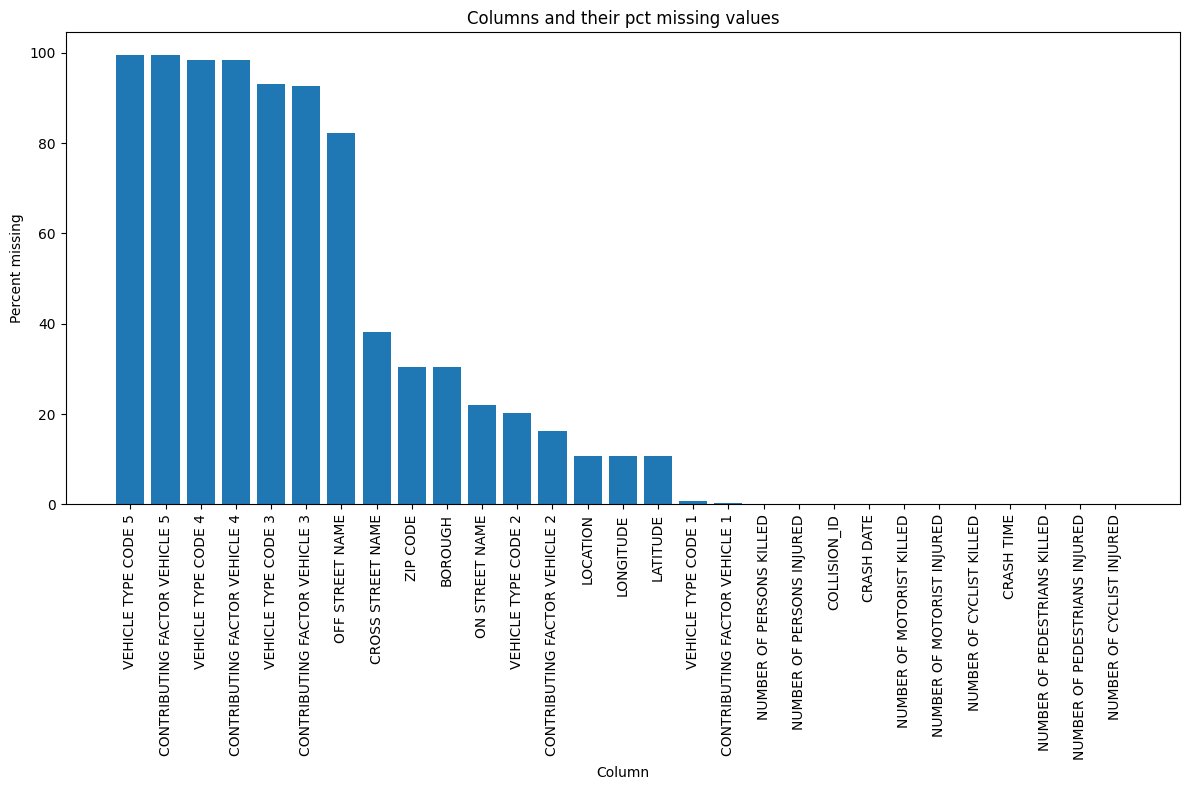

In [8]:
plt.figure(figsize=(12, 8))
plt.bar(missing.index.astype(str), missing["pct_missing"])
plt.xticks(rotation=90)
plt.ylabel("Percent missing")
plt.xlabel("Column")
plt.title("Columns and their pct missing values")
plt.tight_layout()
plt.show()

By inspecting missing values it can be seen from both the table and figure that missingness is highly uneven across variables. Core variables such as "Crash date", "Collision_ID", "Crash time" are complete with most injury/fatality having very few missing values. However several variables from vehicle type code and contributing factor are almost completly missing, which might be due to the fact that there are not many crashes with over three vehicles and contributing factors involved. Street names, borough and zip also has substantial missing values even when the geospatial coordinates are avaliable. Further it can be seen that around 11% of all rows do not contain corrdinates of the incident.   

In [2]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['CRASH DATETIME'] = (
    df['CRASH DATE'].dt.normalize() +
    pd.to_timedelta(df['CRASH TIME'].dt.hour, unit='h') +
    pd.to_timedelta(df['CRASH TIME'].dt.minute, unit='m')
)
print("Date range before cleaning:")
print("Start:", df["CRASH DATETIME"].min())
print("End:", df["CRASH DATETIME"].max())

for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace(['nan', 'None'], pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
    

# Drop rows that dont have spatial or temporal information avaliable.
df_clean =df.dropna(subset=['LATITUDE', 'LONGITUDE','CRASH DATETIME','NUMBER OF PERSONS KILLED','NUMBER OF PERSONS INJURED']).copy()
df_clean.head()
df_clean = df_clean.drop(columns=['CRASH DATE', 'CRASH TIME','LOCATION','VEHICLE TYPE CODE 5','CONTRIBUTING FACTOR VEHICLE 5',
                 'VEHICLE TYPE CODE 4','VEHICLE TYPE CODE 3','CONTRIBUTING FACTOR VEHICLE 4','CONTRIBUTING FACTOR VEHICLE 3',
                 "OFF STREET NAME"])

df_clean = df_clean[~df_clean["CRASH DATETIME"].dt.year.isin([2012, 2026])].copy()
print("Date range after cleaning:")
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Date range before cleaning:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00
Date range after cleaning:
Start: 2013-01-01 00:01:00
End: 2025-12-31 23:58:00


The crash date and crash time varaibles are merged to a combined "Crash datetime" variable. For further analysis all rows with missing geospatial coordinates and number of person/injury are removed since these are important variables that are central in my analysis. Also variables that are not gonna be used in the analysis or variables that contain extreme number of missing values are removed. Also since the dataset contain incomplete data for years 2012 and 2026 they are removed such that the data starts in 2013 and ends in 2025. 

In [3]:
import geopandas as gpd
from shapely.geometry import Point
df_boro = df_clean.copy()

df_boro["BOROUGH"] = (
    df_boro["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .replace("", "Unspecified")
)
gdf_crashes = gpd.GeoDataFrame(
    df_boro,
    geometry=gpd.points_from_xy(df_boro["LONGITUDE"], df_boro["LATITUDE"]),
    crs="EPSG:4326"
)

borough_geojson_url = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson"
boro_gdf = gpd.read_file(borough_geojson_url)
boro_gdf_match = boro_gdf.copy()

if boro_gdf_match.crs is None:
    boro_gdf_match = boro_gdf_match.set_crs("EPSG:4326")
elif boro_gdf_match.crs != gdf_crashes.crs:
    boro_gdf_match = boro_gdf_match.to_crs(gdf_crashes.crs)

possible_boro_cols = ["boroname"]
boro_name_col = next((c for c in possible_boro_cols if c in boro_gdf_match.columns), None)

if boro_name_col is None:
    raise ValueError("Could not find borough name column in boro_gdf")

boro_lookup = boro_gdf_match[[boro_name_col, "geometry"]].copy()

gdf_joined = gpd.sjoin(
    gdf_crashes,
    boro_lookup,
    how="left",
    predicate="within"
)

needs_fill = gdf_joined["BOROUGH"].str.lower().isin(["unspecified","nan"])

gdf_joined.loc[needs_fill, "BOROUGH"] = gdf_joined.loc[needs_fill, boro_name_col].str.upper()

gdf_joined["BOROUGH"] = gdf_joined["BOROUGH"].fillna("Unspecified")

df_clean_filled = df_clean.copy()
df_clean_filled["BOROUGH"] = (
    df_clean_filled["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .replace("", "Unspecified")
)

df_clean_filled.loc[gdf_joined.index, "BOROUGH"] = gdf_joined["BOROUGH"]

before_unspecified = (
    df_clean["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["unspecified", ""])
).sum()

after_unspecified = (
    df_clean_filled["BOROUGH"]
    .fillna("Unspecified")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["unspecified", ""])
).sum()

print(f"Unspecified boroughs before fill: {before_unspecified}")
print(f"Unspecified boroughs after fill:  {after_unspecified}")

Unspecified boroughs before fill: 472110
Unspecified boroughs after fill:  9896


Many rows with missing the borough label while having valid geospatial coordinates. To improve on the borough level analysis, I spatially joined crash coordinates to New York City borough polygons and used these to fill in as many borough labels as possible. As seen we went from having 472.110 missing borough values to 9896, meaning that most boroughs were able to be filled in. The rest of the boroughs that could not be filled in are removed from the data:

In [6]:
df_clean = df_clean_filled.copy()
df_clean = df_clean[
    ~df_clean["BOROUGH"].isin(["Unspecified"])
].copy()
df_clean["BOROUGH"].unique()

array(['BROOKLYN', 'BRONX', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'],
      dtype=object)

After removing the approximately 10.000 rows that could not be filled with boroughs, the only boroughs that are left in the dataset are now the five correct NYC boroughs. 

In [8]:
is_kill_bal = df["NUMBER OF PERSONS KILLED"] == df["NUMBER OF MOTORIST KILLED"] + df["NUMBER OF CYCLIST KILLED"] + df["NUMBER OF PEDESTRIANS KILLED"]
print(len(is_kill_bal[is_kill_bal==False]))
is_inj_bal = df["NUMBER OF PERSONS INJURED"] == df["NUMBER OF MOTORIST INJURED"] + df["NUMBER OF CYCLIST INJURED"] + df["NUMBER OF PEDESTRIANS INJURED"]
print(len(is_inj_bal[is_inj_bal==False]))

113
10640


One thing that i could not find an exact definition on in the raw dataset was whether the number of person injured/killed represented the sum of the three subcategories. By checking this it can be seen that for most rows it do indeed match, however there are some inconsistensies still. These inconsistensies might be caused by passenger differences or possbly recording mistakes. Since the mismatches were limited, I decided to treat number of persons injured/killed as the total sum of the subcategories hence i removed all the rows that had these mismatches to ensure consistency. 

In [9]:
df_clean = df_clean.copy()
df_clean = df_clean[
    ~(
        (df_clean["NUMBER OF PERSONS INJURED"] != (
            df_clean["NUMBER OF PEDESTRIANS INJURED"]
            + df_clean["NUMBER OF CYCLIST INJURED"]
            + df_clean["NUMBER OF MOTORIST INJURED"]
        ))
        |
        (df_clean["NUMBER OF PERSONS KILLED"] != (
            df_clean["NUMBER OF PEDESTRIANS KILLED"]
            + df_clean["NUMBER OF CYCLIST KILLED"]
            + df_clean["NUMBER OF MOTORIST KILLED"]
        ))
    )
].copy()

In [13]:
print(df_clean.shape)
print(df.shape[0]-df_clean.shape[0])

(1887039, 20)
366153


After data-preprocessing there are a little under 1.9 million incidents left and 20 variables. This means that 366153 incidents were removed, most of which due to not having geospatial information avaliable. Further 9 variables were removed since they either had too many missing values or were not useful for the analysis. 

### 2.2 Section that discuss the dataset stats and that contain key plots from the exploratory data analysis

In [24]:
df_stats = df_clean.copy()
num_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST INJURED",
    "NUMBER OF MOTORIST KILLED",
]
for col in num_cols:
    df_stats[col] = pd.to_numeric(df_stats[col], errors="coerce").fillna(0)
n_crashes = len(df_stats)

start_date = df_stats["CRASH DATETIME"].min()
end_date = df_stats["CRASH DATETIME"].max()

injury_crashes = (df_stats["NUMBER OF PERSONS INJURED"] > 0).sum()
fatal_crashes = (df_stats["NUMBER OF PERSONS KILLED"] > 0).sum()

total_injured = df_stats["NUMBER OF PERSONS INJURED"].sum()
total_killed = df_stats["NUMBER OF PERSONS KILLED"].sum()

ped_injured = df_stats["NUMBER OF PEDESTRIANS INJURED"].sum()
cyc_injured = df_stats["NUMBER OF CYCLIST INJURED"].sum()
mot_injured = df_stats["NUMBER OF MOTORIST INJURED"].sum()

ped_killed = df_stats["NUMBER OF PEDESTRIANS KILLED"].sum()
cyc_killed = df_stats["NUMBER OF CYCLIST KILLED"].sum()
mot_killed = df_stats["NUMBER OF MOTORIST KILLED"].sum()

injury_crash_pct = 100 * injury_crashes / n_crashes if n_crashes else np.nan
fatal_crash_pct = 100 * fatal_crashes / n_crashes if n_crashes else np.nan

injuries_per_crash = total_injured / n_crashes if n_crashes else np.nan
injuries_per_injury_crash = total_injured / injury_crashes if injury_crashes else np.nan

fatalities_per_crash = total_killed / n_crashes if n_crashes else np.nan
fatalities_per_fatal_crash = total_killed / fatal_crashes if fatal_crashes else np.nan

injury_to_fatality_ratio = total_injured / total_killed if total_killed else np.nan

ped_injury_share = 100 * ped_injured / total_injured if total_injured else np.nan
cyc_injury_share = 100 * cyc_injured / total_injured if total_injured else np.nan
mot_injury_share = 100 * mot_injured / total_injured if total_injured else np.nan

ped_fatal_share = 100 * ped_killed / total_killed if total_killed else np.nan
cyc_fatal_share = 100 * cyc_killed / total_killed if total_killed else np.nan
mot_fatal_share = 100 * mot_killed / total_killed if total_killed else np.nan

days_covered = (end_date - start_date).days if pd.notna(start_date) and pd.notna(end_date) else np.nan
crashes_per_day = n_crashes / days_covered if days_covered and days_covered > 0 else np.nan
injured_per_day = total_injured / days_covered if days_covered and days_covered > 0 else np.nan
killed_per_day = total_killed / days_covered if days_covered and days_covered > 0 else np.nan

summary_stats = pd.DataFrame({
    "Metric": [
        "Number of crashes",
        "Start date",
        "End date",
        "Crashes with injuries",
        "Crashes with fatalities",
        "Percent of crashes with injuries",
        "Percent of crashes with fatalities",
        "Total persons injured",
        "Total persons killed",
        "Average injuries per crash",
        "Average injuries per injury crash",
        "Average fatalities per crash",
        "Average fatalities per fatal crash",
        "Injury-to-fatality ratio",
        "Pedestrian share of injuries",
        "Cyclist share of injuries",
        "Motorist share of injuries",
        "Pedestrian share of fatalities",
        "Cyclist share of fatalities",
        "Motorist share of fatalities",
        "Average crashes per day",
        "Average injured persons per day",
        "Average killed persons per day",
    ],
    "Value": [
        n_crashes,
        start_date,
        end_date,
        injury_crashes,
        fatal_crashes,
        injury_crash_pct,
        fatal_crash_pct,
        total_injured,
        total_killed,
        injuries_per_crash,
        injuries_per_injury_crash,
        fatalities_per_crash,
        fatalities_per_fatal_crash,
        injury_to_fatality_ratio,
        ped_injury_share,
        cyc_injury_share,
        mot_injury_share,
        ped_fatal_share,
        cyc_fatal_share,
        mot_fatal_share,
        crashes_per_day,
        injured_per_day,
        killed_per_day,
    ]
})

summary_stats

,Metric,Value
0,Number of crashes,1887039
1,Start date,2013-01-01 00:01:00
2,End date,2025-12-31 23:58:00
3,Crashes with injuries,461692
4,Crashes with fatalities,2772
5,Percent of crashes with injuries,24.466479
6,Percent of crashes with fatalities,0.146897
7,Total persons injured,622941.0
8,Total persons killed,2893.0
9,Average injuries per crash,0.330116


As previously mentioned the dataset contains 1887039 police reported crash incidents in NYC ranging from 2013-2025. This corrosponds to about an average of 397 crashes per day, although there is a substantial variation throughout the days which can be seen in the next figure. Across the full dataset we can see that around 24.5% of crashes contain at least one injury whereas 0.15% contain at least one fatality. This indicates that fatalities are much rarer than injuries while injuries happen around one fourth of every recorded crash. In total, the dataset has records of 461.692 crashes with at least one injury and 2772 crashes with at least one fatality. This corrosponds to around 0.33 injuries per crash and 1.35 injuries per injury crash which shows that injuries happen relativly often in crashes and crashes with injuries often invovle more than one injured person. For fatal crashes we see that 1.04 fatalities per crash indicate that often fatal crashes result in a single death on average. Overall the dataset contain approximatly 215 injuries for every fatality which shows that non fatal harm is much more common than fatal outcomes, however generally crash harm is very frequent and injuries happen relativly often.  

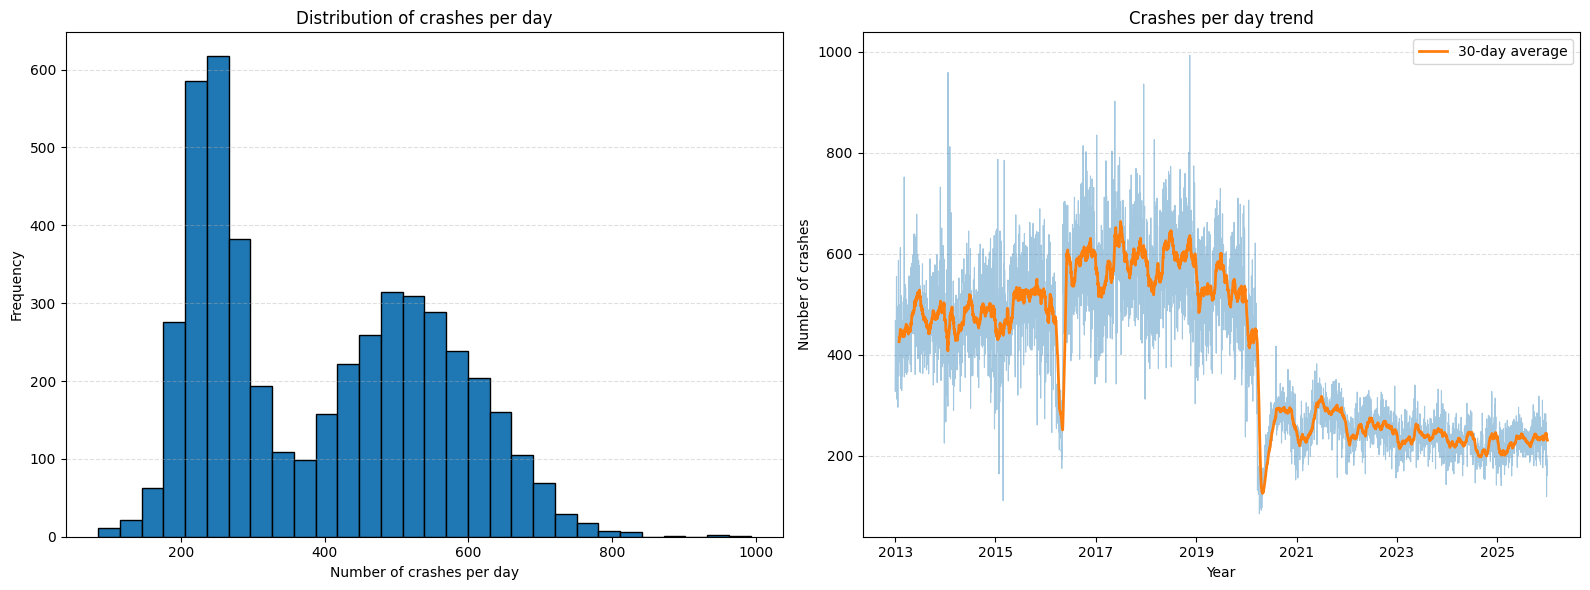

In [22]:
crashes_per_day = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.date)
      .size()
)

rolling_30 = crashes_per_day.rolling(30).mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(crashes_per_day, bins=30,edgecolor="black")
axes[0].set_xlabel("Number of crashes per day")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of crashes per day")
axes[0].grid(True,axis="y",linestyle="--",alpha=0.4)

axes[1].plot(crashes_per_day.index, crashes_per_day.values, linewidth=0.8, alpha=0.4)
axes[1].plot(rolling_30.index, rolling_30.values, linewidth=2, label="30-day average")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of crashes")
axes[1].set_title("Crashes per day trend")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1].set_axisbelow(True)

tick_years = pd.date_range("2013-01-01", crashes_per_day.index.max(), freq="2YS")
axes[1].set_xticks(tick_years)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend()

plt.tight_layout()
plt.show()


This figure shows the distribution of crahes per day in the left panel and the time series of car crashes in the right panel. The right panel shows that the number of crashes each day vary a lot across the time period. The average crashes per day was seen to be around 397, however the figure reveals that daily crash counts were generally higher during 2013-2019 with a single large drop during late 2016. This was followed by a large drop in crashes after 2020 whereafter the trend remains fairly stable and never reallt recovered to the historical crash average. This is also supported by the histogram in the left panel which shows a wide spread in daily crash counts and a bimodel distribution where the first peak around 300 seems to be after 2020 and the second peak at around 500 is before.

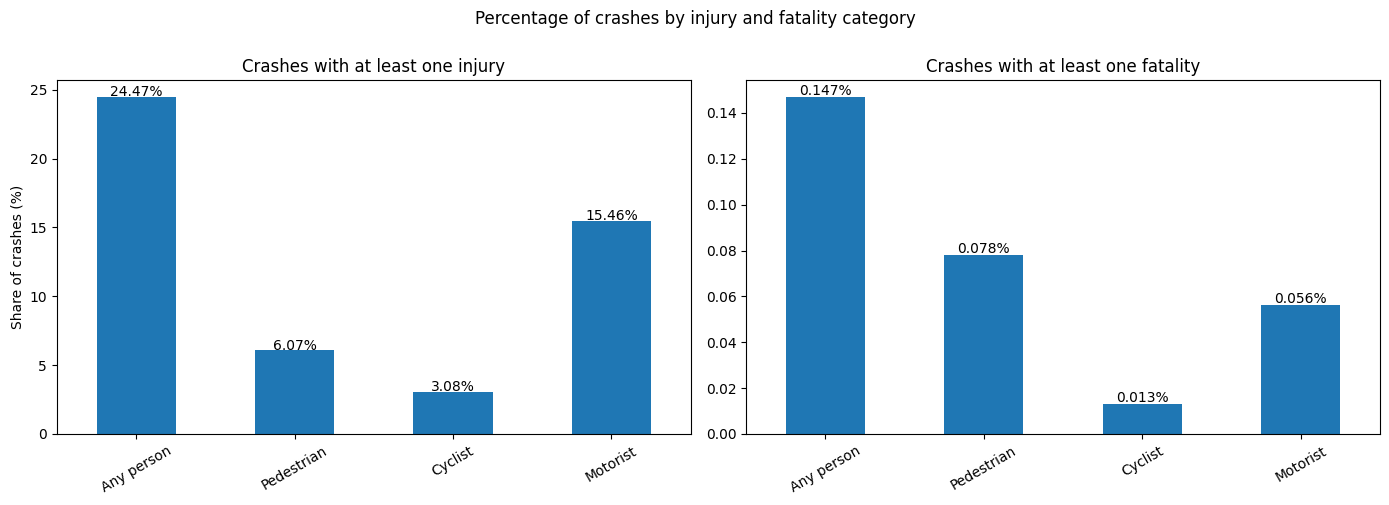

In [23]:
injury_fractions = {
    "Any person": (df_clean["NUMBER OF PERSONS INJURED"] > 0).mean(),
    "Pedestrian": (df_clean["NUMBER OF PEDESTRIANS INJURED"] > 0).mean(),
    "Cyclist": (df_clean["NUMBER OF CYCLIST INJURED"] > 0).mean(),
    "Motorist": (df_clean["NUMBER OF MOTORIST INJURED"] > 0).mean(),
}
fatality_fractions = {
    "Any person": (df_clean["NUMBER OF PERSONS KILLED"] > 0).mean(),
    "Pedestrian": (df_clean["NUMBER OF PEDESTRIANS KILLED"] > 0).mean(),
    "Cyclist": (df_clean["NUMBER OF CYCLIST KILLED"] > 0).mean(),
    "Motorist": (df_clean["NUMBER OF MOTORIST KILLED"] > 0).mean(),
}
injury_series = pd.Series(injury_fractions) * 100
fatality_series = pd.Series(fatality_fractions) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
injury_series.plot(kind="bar", ax=ax1)
ax1.set_title("Crashes with at least one injury")
ax1.set_ylabel("Share of crashes (%)")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=30)

for i, v in enumerate(injury_series):
    ax1.text(i, v + 0.05, f"{v:.2f}%", ha="center")

ax2 = axes[1]
fatality_series.plot(kind="bar", ax=ax2)
ax2.set_title("Crashes with at least one fatality")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=30)

for i, v in enumerate(fatality_series):
    ax2.text(i, v + max(fatality_series) * 0.03 - 0.0035, f"{v:.3f}%", ha="center")

plt.suptitle("Percentage of crashes by injury and fatality category", y=1.00)
plt.tight_layout()
plt.show()

This figure gives an overview on how the share of crashes involving at least one injury or fatality distribute across road user category. As previously mentioned injury crashes involving any person is fairly frequent which can be seen in roughly 25% of all recorded crashes, whereas fatalities only in roughly 0.15% of crashes. Motorists appear to account for the largest share of injury related crashes at 15.5%, followed by pedestrians at 6% and cyclists at 3%. For fatalities the percentages are smaller overall, however the largest share of fatal crashes happen to pedestrians at 0.078% followed by motorists at 0.056%, whereas cyclists account for a very small relative percentage at 0.013%. This shows that fatalities are fairly rare compared to injuries and that the distribution of harm is uneven across the road type users.

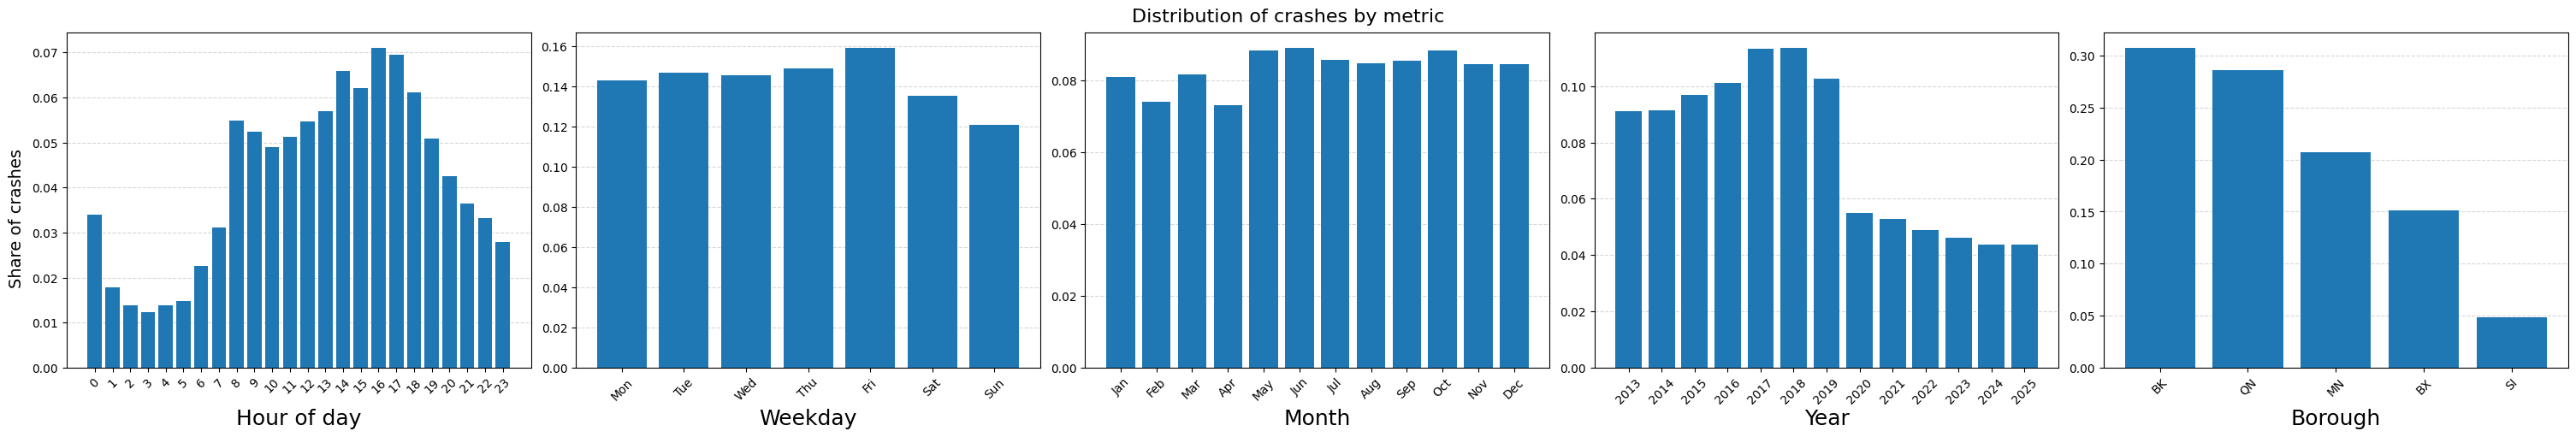

In [20]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
crashes_by_weekday = (
    df_clean.assign(weekday=df_clean["CRASH DATETIME"].dt.strftime("%a"))
    .groupby("weekday")
    .size()
    .reindex(weekday_order, fill_value=0)
)
crashes_by_hour = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.hour)
    .size()
    .reindex(range(24), fill_value=0)
)
crashes_by_year = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.year)
    .size()
    .sort_index()
)
borough_map = {
    "BRONX": "BX",
    "BROOKLYN": "BK",
    "MANHATTAN": "MN",
    "QUEENS": "QN",
    "STATEN ISLAND": "SI",
}
crashes_by_borough = (
    df_clean["BOROUGH"]
      .fillna("Unknown")
      .replace(borough_map)
      .value_counts()
      .reindex(["BX", "BK", "MN", "QN", "SI"], fill_value=0)
)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

crashes_by_month = (
    df_clean.assign(month=df_clean["CRASH DATETIME"].dt.strftime("%b"))
    .groupby("month")
    .size()
    .reindex(month_order, fill_value=0)
)
crashes_by_month_share = crashes_by_month / crashes_by_month.sum()
crashes_by_hour_share = crashes_by_hour / crashes_by_hour.sum()
crashes_by_weekday_share = crashes_by_weekday / crashes_by_weekday.sum()
crashes_by_year_share = crashes_by_year / crashes_by_year.sum()
crashes_by_borough = crashes_by_borough.sort_values(ascending=False)
crashes_by_borough_share = crashes_by_borough / crashes_by_borough.sum()
fig, axes = plt.subplots(1, 5, figsize=(30, 5), constrained_layout=True)
axes[0].bar(crashes_by_hour.index, crashes_by_hour_share.values)
axes[0].set_xlabel("Hour of day",fontsize=18)
axes[0].set_xticks(range(24))
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(crashes_by_weekday.index, crashes_by_weekday_share.values)
axes[1].set_xlabel("Weekday",fontsize=18)
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(crashes_by_month.index, crashes_by_month_share.values)
axes[2].set_xlabel("Month",fontsize=18)
axes[2].tick_params(axis="x", rotation=45)

axes[3].bar(crashes_by_year.index.astype(str), crashes_by_year_share.values)
axes[3].set_xlabel("Year",fontsize=18)
axes[3].tick_params(axis="x", rotation=45)

axes[4].bar(crashes_by_borough.index.astype(str), crashes_by_borough_share.values)
axes[4].set_xlabel("Borough",fontsize=18)
axes[4].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.xaxis.set_label_coords(0.5, -0.12)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Distribution of crashes by metric", fontsize=16)
fig.supylabel("Share of crashes", fontsize=14)
plt.show()

This figure provides a compact overview of crash distributions across hour, weekday, month, year and borough. Crashes are seen to be least frequent during the night hours and early morning, whereafter they begin to rise during the day, peaking in the afternoon and early evening. The weekday variation appear to be less substantial with friday accounting for a slightly larger share of crashes compared to the rest of the weekdays. The weekend appear to contain a smaller share of crashes compared to the weekdays with sunday having the smallest share. Monthly crash shares seem to be relativly similar, indicating that seasonality might not show a large variation in an overview like this. Looking at the yearly distribution we can see the same story as the timeseries, where the years before 2020 had a substantially larger share of crash incidents. It can also be seen that the share of crash incidents after 2020 appear to be slowly decreasing towawrd 2025. Across boroughs, Brooklyn accounts for the largest share of crash incidents followed closely by Queens. Manhatten comes next followed by Bronx and finally Staten Island which contribute by a much smaller share of car crashes than the rest of the boroughs. 

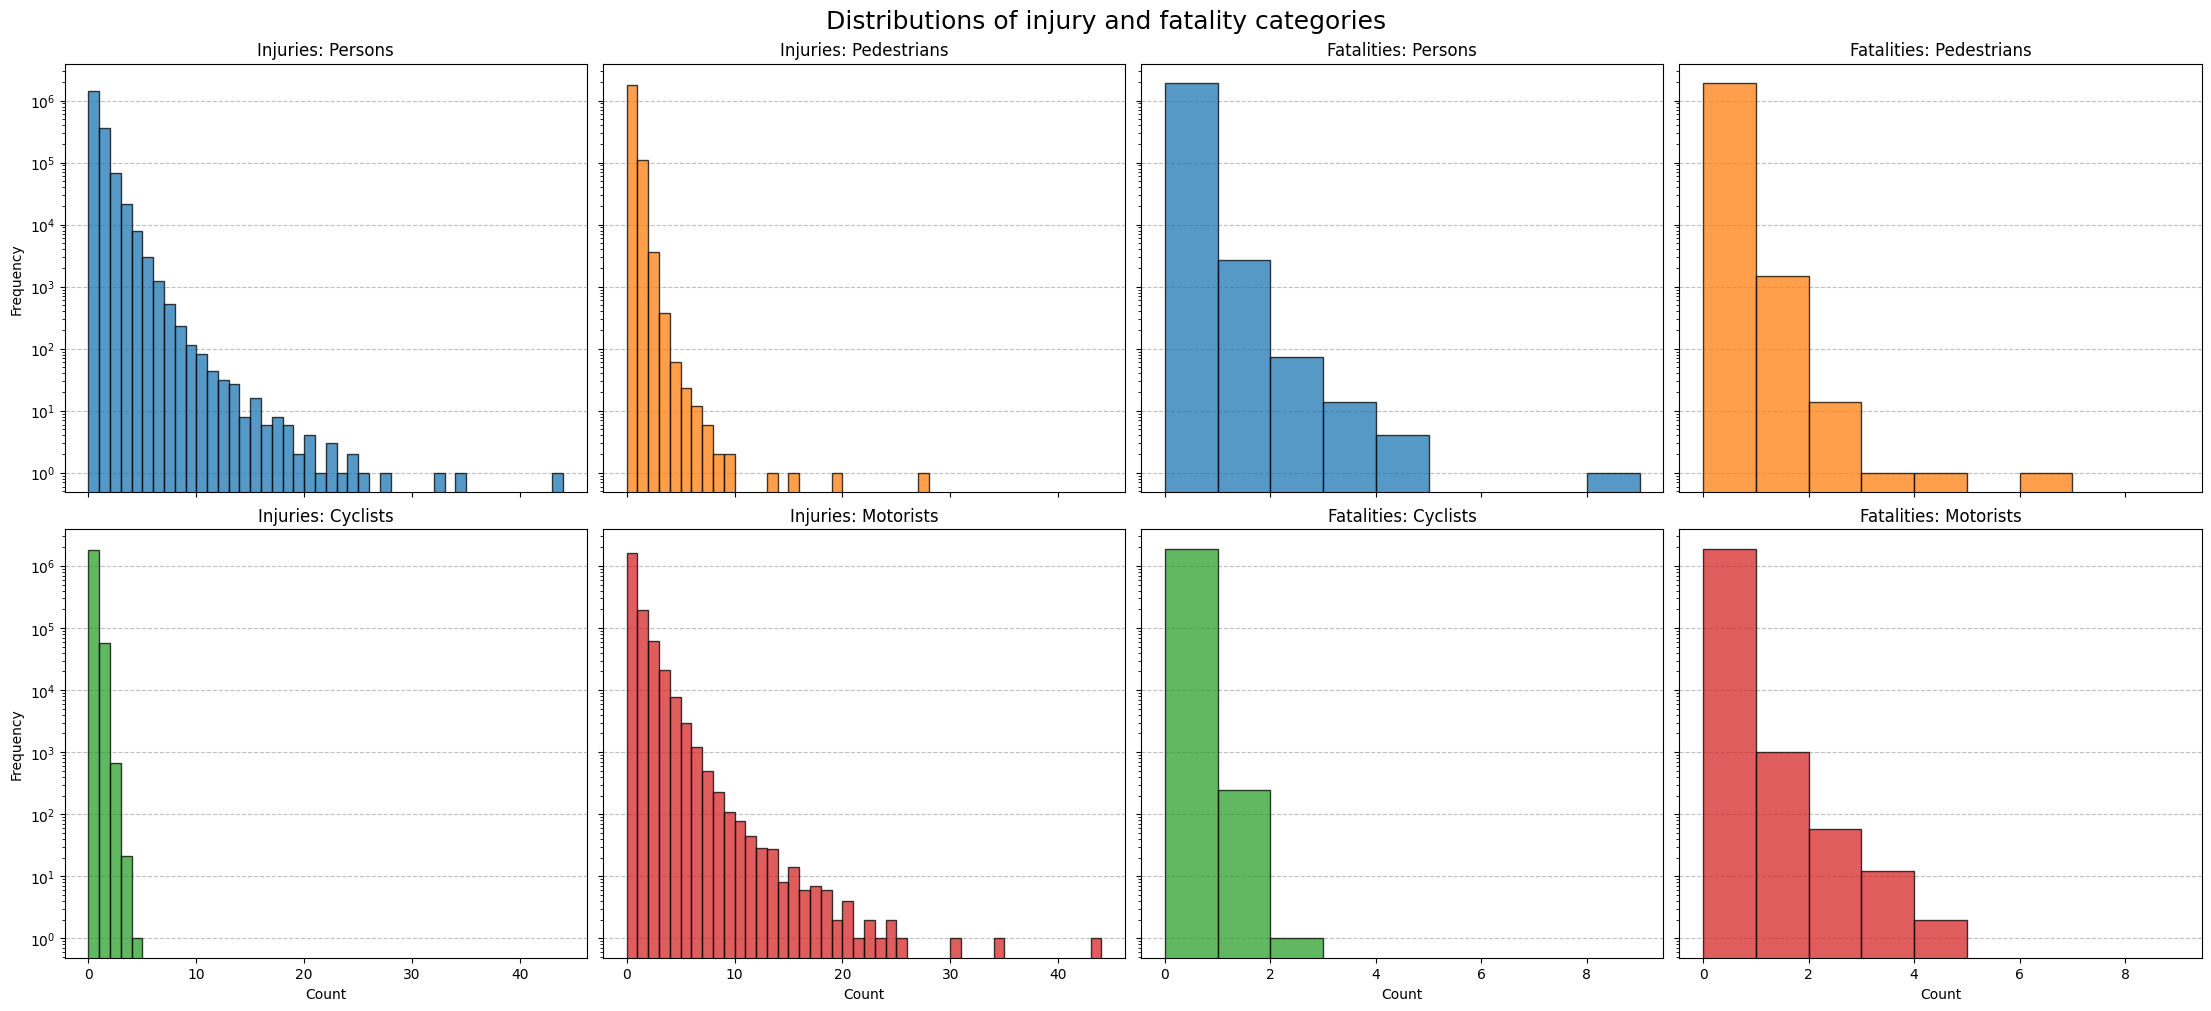

In [21]:
injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

injury_labels = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

fatality_labels = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

injury_colors = {
    "NUMBER OF PERSONS INJURED": "tab:blue",
    "NUMBER OF PEDESTRIANS INJURED": "tab:orange",
    "NUMBER OF CYCLIST INJURED": "tab:green",
    "NUMBER OF MOTORIST INJURED": "tab:red",
}

fatality_colors = {
    "NUMBER OF PERSONS KILLED": "tab:blue",
    "NUMBER OF PEDESTRIANS KILLED": "tab:orange",
    "NUMBER OF CYCLIST KILLED": "tab:green",
    "NUMBER OF MOTORIST KILLED": "tab:red",
}

for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

inj_bins = range(0, int(df_clean[injured_cols].max().max()) + 2)
kill_bins = range(0, int(df_clean[killed_cols].max().max()) + 2)

fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True, sharey='row',sharex='col')

inj_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (r, c), col in zip(inj_positions, injured_cols):
    ax = axes[r, c]
    vals = df_clean[col].dropna()

    ax.hist(
        vals,
        bins=inj_bins,
        color=injury_colors[col],
        alpha=0.75,
        edgecolor="black",
        label=injury_labels[col]
    )

    ax.set_title(f"Injuries: {injury_labels[col]}")
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", alpha=0.8)
    ax.set_axisbelow(True)

kill_positions = [(0, 2), (0, 3), (1, 2), (1, 3)]

for (r, c), col in zip(kill_positions, killed_cols):
    ax = axes[r, c]
    vals = df_clean[col].dropna()

    ax.hist(
        vals,
        bins=kill_bins,
        color=fatality_colors[col],
        alpha=0.75,
        edgecolor="black",
        label=fatality_labels[col]
    )

    ax.set_title(f"Fatalities: {fatality_labels[col]}")
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", alpha=0.8)
    ax.set_axisbelow(True)

axes[0, 0].set_ylabel("Frequency")
axes[1, 0].set_ylabel("Frequency")
axes[1,0].set_xlabel("Count")
axes[1,1].set_xlabel("Count")
axes[1,2].set_xlabel("Count")
axes[1,3].set_xlabel("Count")

fig.suptitle("Distributions of injury and fatality categories", fontsize=18)
plt.show()

The final figure shows the distribution of injury and fatalities across the different road type users. All the distributions appear to be heavily skewed toward the right with most crashes involving zero or few injuries/fatalities. It can be seen that only a few crashes involve larger counts of injuries/fatalities, however there are a few outliers especially for the injury category. The pattern is especially clear for fatalities where most of the crashes involve zero deaths and a very small number invovlves more than one. For injuries it can be seen again that motorist make up the largest counts and variation, where the distributions for pedestrians and cyclists are concentrated more around the smaller counts. 

These figures overall suggest that the problem is not only large in scale but also uneven in severity. Fatalities are rare compared to injuries, however they remain present across the time period. The harmful crashes also distribute differently across the road type users. Motorist seem to dominate the injury counts, while pedestrians are more prominent in fatal outcomes. It appears that crash harm can not be understood from crash totals alone.

## 3. Data analysis

### 3.1 Describe yuor data analysis and explain what I heave learned about the dataset

#### 3.1.1 Data source & source
The dataset is based on police reported crash data with each row representing a reported crash incident. The incidents have to be reported if they follow thr requirements stated earlier, meaning if either an injury/fatality happened or at least 1000$ worth of damage is present. This indicates that crash incidents has to meet this threshold to be reported hence not all crashes end up in the dataset. The threshold imply that more severe incidents are recorded while many incidents might not make it into the report due to not meeting this threshold. Therefore the dataset might be better at describing recorded crash harm rather than total true crash incidents. 

#### 3.1.2 Variable quality in dataset

From analyzing the dataset I saw that there are many variables that have substantial amount of missing values. Most of the core variables like time, coordinates, harm categories and crash id's were strong and mostly complete. Many of the multi vehicle and factor categories were sparse and cominated by missing values which can be expected since crashes with multiple vehicles and factors might be less frequent. However both for the primary contributing factor and boroughs there were many "unspecified" or missing values which limits usability a bit. I did however recover the borough information by using the coordinates.

#### 3.1.3 What affacted crashes over time

I noticed that years 2012 and 2026 were incomplete. The dataset most likely started documenting the reported crash incidents sometime during 2012 and since the dataset is continiously updated this is expected. The analysis showed that 2020 marked a large decrease in crash incidents and has since then not returned to the previous magnitude of crash counts. Possible police reporting changes could change the data and intepretation substantially hence it should be considered carefully, however I have not found anything that indicates any changes for this dataset. Lastly fatalities appear to be much rarer than injuries and althogh there is a stable trend still seem to be noiser than the injuries.

#### 3.1.4 What can and cant the dataset tell

Due to the threshold of the police reporting of the crashes, the dataset can show us patterns in reported crash harm, however not describe the overall crashes of New York City since many might not be reported. The dataset can not establish causiality of crash incidents. There are many underlying processes that can cause crash incidents like weather conditions, traffic densities, road design and construction, vehicle issues etc. which are not documented in this dataset. This means that while we can observe patterns for crash harm and contributing factors to the crashes we can not conclude anything on why the crash actually happened or what the actual reason was. This is also why the dataset can not be a basis for estimating the risk of crashes for road users.



## 4. Genre

### 4.1 Which tools did i use from each of the three categories of visual narrative
The genre is mainly magazine style with martini glass structure. The story starts off by being author driven with illustrations to support the text. The last section is a big interactive map which the reader can explore the dataset themselves hence the martini glass structure.

#### 4.1.1 Visual structuring
For visual structuring I have used an **establihsing shot** at the start to introduce the topic to the reader and give them an understanding and a starting point before going into details. Further I have used a **Consistent visual platform** by structuring each section in the same layout with consistent figure cards, captions, titles, and similar color pallete when possible. 

#### 4.1.2 Highlighting
For highlighting i have primarily used **Feature distinction**. I have done this by directing the readers attention toward important elements by having clear bold titles, highlighting figures by using cards and framing them, colored labels and legends on figures and numbers on e.g barplots if I thought that the numbers were important for the story.

#### 4.1.3 Transition Guidiance
For transition guidance I have not specifically used one of the elements completly explicitly. The website have a smooth transition between sections and the sections are carefully ordered such that we have a natural transition. I have also made sure to have a bridge between the sections in the text. **Object continuity** fits best since the figures stay visible when scrolling so the reader can understand what is changing during the transition through the website.


### 4.2 Which tools did i use from each of the three categories of narrative structure

#### 4.2.1 Ordering
The ordering is mainly **Linear** since the reader has a clear fixed path in the beginnig and move through different guided narrative sections. At the end, the website opens up into a **User-directed** exploration through the interactive map. This follows the martini glass structure.

#### 4.2.2 Interactivity
There are two interactive illustrations on the website. **Hover Highlighting/Details** is used since it is possible to hover over parts of both figures to get information. For the interactive map it is possible to select and filter certain parts of the data depending on what the reader wants to see hence **Filtering/Selection/Search** is used on this. Also since there are multiple options for the interactive map I have included a small paragraph that explains how the reader can interact with it hence using the **Explicit instruction**. There are also navigational buttons in the top bar of the website which uses the **Navigation buttons** interactivity.

#### 4.2.3 Messaging
The website relies on the messaging structure narrative structure through **captions/headlines** for each section and figure, **Summary/Synthesis** for explaining each section and bringing the findings together and **Accompanying article** by the paragraphs of text that support the visualizations. These are seen through the website story to make the findings more understandable for the reader.

## 5. Visualizations

* Explain the visualizations i have chosen
* Why are they right for telling this story?

* Q: Should i have the visualizations inside the notebook here? Yes

## 6. Discussion

* What went well?
* What is still missing? What would be improved?, Why?

## 7. Contributions

* This entire project is made by Magnus Elfenbein s214710